# Magnetic Field Reconstruction from ODMR Branch Splittings

This notebook implements a complete workflow for extracting the bias magnetic field **b₀** and the apparatus response matrix **H** from ODMR spectroscopy data.

## Workflow Summary

1. **Load fitted ODMR data** from `fitlorenzo.ipynb` results (x₁ centers for each branch)
2. **Extract linear slopes**: fit νᵢ(uα) = mᵢα·uα + bᵢ for all 8 branches across X, Y, Z scans
3. **Pair left/right branches** into 4 candidate NV axes
4. **Validate pairs** via smoothness and consistency checks
5. **Try all 24 permutations** of assigning pairs to the 4 tetrahedral NV directions
6. **Find best assignment** by minimizing prediction residual on reference spectrum
7. **Determine b₀** in crystal frame from reference spectrum
8. **Build apparatus matrix H** from measured slopes
9. **Report final results**: axis assignment, b₀, and H matrix

## Physical Foundation

In the linear Zeeman regime, the resonance frequency of NV branch i under applied field **b** is:

$$\nu_i(\mathbf{b}) = D + \gamma_e (\mathbf{n_i} \cdot \mathbf{b})$$

where **nᵢ** is the NV center axis direction, γₑ ≈ 2.8 MHz/mT is the electron Zeeman constant, and D ≈ 2.87 GHz is the zero-field splitting.

As we vary actuator position **u** = (uₓ, uᵧ, u_z), the magnetic field changes linearly:

$$\mathbf{b}(\mathbf{u}) = \mathbf{b_0} + \mathbf{H} \mathbf{u}$$

where **b₀** is the zero-offset bias field and **H** is the apparatus response matrix.

## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares
from itertools import permutations
import os
import warnings
warnings.filterwarnings('ignore')

# Physical constants
gamma_e = 2.8e-3  # MHz/mT (electron Zeeman constant)
D_GHz = 2.87      # Zero-field splitting reference

# NV tetrahedral axes in diamond crystal frame
NV_AXES = np.array([
    np.array([1, 1, 1]),
    np.array([-1, -1, 1]),
    np.array([-1, 1, -1]),
    np.array([1, -1, -1])
]) / np.sqrt(3)

print("NV tetrahedral axes (diamond frame):")
for i, n in enumerate(NV_AXES, 1):
    print(f"  n{i} = {n}")

NV tetrahedral axes (diamond frame):
  n1 = [0.57735027 0.57735027 0.57735027]
  n2 = [-0.57735027 -0.57735027  0.57735027]
  n3 = [-0.57735027  0.57735027 -0.57735027]
  n4 = [ 0.57735027 -0.57735027 -0.57735027]


## Part 1: Load Results from fitlorenzo

Extract the central hyperfine line (x₁) from each fitted result and organize by variation (X, Y, Z) and offset.

In [2]:
def load_odmr_results(base_path='.'):
    """
    Load all fitted ODMR results from fitlorenzo output folders.
    
    Returns
    -------
    data : dict
        Structure: data['Variation Along X']['offsets'] = array of offsets (mm)
                   data['Variation Along X']['branches'] = DataFrame with columns [offset, dip_id, x1_GHz]
    """
    data = {}
    variations = ['Variation Along X', 'Variation Along Y', 'Variation Along Z']
    
    for variation in variations:
        folder = f'./{variation}'
        if not os.path.exists(folder):
            print(f"Warning: {folder} not found")
            continue
        
        # Find all _results.csv files
        results_files = [f for f in os.listdir(folder) if f.endswith('_results.csv')]
        if not results_files:
            print(f"Warning: No _results.csv files in {folder}")
            continue
        
        # Parse offsets and sort
        def get_offset(filename):
            base = filename.replace('_results.csv', '')
            parts = base.split('-')
            offset_str = parts[-1].replace('mm', '')
            return float(offset_str)
        
        results_files.sort(key=get_offset)
        offsets = [get_offset(f) for f in results_files]
        
        # Load all data
        branches_list = []
        for fname, offset in zip(results_files, offsets):
            df = pd.read_csv(os.path.join(folder, fname))
            # Extract x1_GHz (central hyperfine line) and dip_id
            for _, row in df.iterrows():
                branches_list.append({
                    'offset': offset,
                    'dip_id': int(row['dip_id']),
                    'x1_GHz': row['x1_GHz'],
                    'dip_side': row['dip_side']
                })
        
        branches_df = pd.DataFrame(branches_list)
        data[variation] = {
            'offsets': np.array(offsets),
            'branches': branches_df
        }
        print(f"Loaded {variation}: {len(offsets)} offsets, {len(branches_df)} branch measurements")
    
    return data

# Load the data
data = load_odmr_results()
print("\nData loaded successfully.")

Loaded Variation Along X: 5 offsets, 40 branch measurements
Loaded Variation Along Y: 5 offsets, 40 branch measurements
Loaded Variation Along Z: 6 offsets, 48 branch measurements

Data loaded successfully.


## Part 2: Linear Fitting and Build Response Matrix Jᵤ

For each branch i and each scan direction α ∈ {X, Y, Z}, fit:
$$\nu_i(u_\alpha) = m_{i\alpha} u_\alpha + b_i$$

In [3]:
def fit_linear_slopes(data):
    """
    Fit linear slopes for each branch in each direction.
    
    Returns
    -------
    slopes : dict
        slopes[direction][dip_id] = {'m': slope, 'b': intercept, 'r2': R-squared}
    J_u : ndarray, shape (8, 3)
        Measured response matrix: rows are branches 1-8, columns are X, Y, Z
    """
    slopes = {}
    J_u_rows = []
    
    variations = ['Variation Along X', 'Variation Along Y', 'Variation Along Z']
    directions = ['X', 'Y', 'Z']
    
    for direction, variation in zip(directions, variations):
        slopes[direction] = {}
        df = data[variation]['branches']
        offsets = data[variation]['offsets']
        
        # For each dip_id (branch), fit linear model
        for dip_id in range(1, 9):
            dip_data = df[df['dip_id'] == dip_id].sort_values('offset')
            if len(dip_data) < 2:
                print(f"Warning: Dip {dip_id} in {direction} has < 2 points")
                continue
            
            u_vals = dip_data['offset'].to_numpy()
            nu_vals = dip_data['x1_GHz'].to_numpy()
            
            # Linear fit
            m, b = np.polyfit(u_vals, nu_vals, 1)
            y_fit = m * u_vals + b
            ss_res = np.sum((nu_vals - y_fit) ** 2)
            ss_tot = np.sum((nu_vals - np.mean(nu_vals)) ** 2)
            r2 = 1.0 - (ss_res / (ss_tot + 1e-15))
            
            slopes[direction][dip_id] = {
                'm': m,
                'b': b,
                'r2': r2
            }
    
    # Build J_u matrix (8 branches x 3 directions)
    J_u = np.zeros((8, 3))
    for col, direction in enumerate(directions):
        for dip_id in range(1, 9):
            if dip_id in slopes[direction]:
                J_u[dip_id - 1, col] = slopes[direction][dip_id]['m']
    
    return slopes, J_u

# Fit slopes
slopes, J_u = fit_linear_slopes(data)

print("\nFitted J_u matrix (∂ν/∂u):")
print("Rows: dip 1-8, Columns: X, Y, Z")
print(J_u)
print(f"\nR² values for linear fits:")
for direction in ['X', 'Y', 'Z']:
    r2_vals = [slopes[direction].get(i, {}).get('r2', np.nan) for i in range(1, 9)]
    print(f"  {direction}: {np.nanmean([r for r in r2_vals if not np.isnan(r)]):.4f} (mean)")


Fitted J_u matrix (∂ν/∂u):
Rows: dip 1-8, Columns: X, Y, Z
[[-0.0073453   0.00050634  0.00058174]
 [-0.00489993 -0.00399752 -0.003731  ]
 [ 0.00189518  0.0024134  -0.00435969]
 [ 0.00432635 -0.00233221 -0.00270291]
 [-0.00321521 -0.01396455  0.00449491]
 [-0.00098652  0.00157524  0.00511492]
 [ 0.00533841  0.01269885  0.00489952]
 [ 0.00730394 -0.01227286  0.00509143]]

R² values for linear fits:
  X: 0.9749 (mean)
  Y: 0.5468 (mean)
  Z: 0.8600 (mean)


## Part 3: Pair Left and Right Branches

Identify which left and right dips belong to the same NV axis by finding pairs closest to D.

In [6]:
def identify_left_right_branches(data):
    """
    Identify left (< 2.87 GHz) and right (> 2.87 GHz) branches from reference spectrum.
    
    Returns
    -------
    left_dips : list of dip_ids (1-4)
    right_dips : list of dip_ids (5-8)
    reference_data : dict with x1_GHz for each dip at zero offset
    """
    # Use first variation and zero offset as reference
    variation = 'Variation Along X'
    df = data[variation]['branches']
    
    # Get data at zero offset
    ref_data = df[df['offset'] == 0.0].sort_values('x1_GHz')
    
    left_dips = []
    right_dips = []
    reference = {}
    
    for _, row in ref_data.iterrows():
        dip_id = int(row['dip_id'])
        x1 = row['x1_GHz']
        reference[dip_id] = x1
        
        if x1 < D_GHz:
            left_dips.append(dip_id)
        else:
            right_dips.append(dip_id)
    
    left_dips.sort(key=lambda x: reference[x], reverse=True)  # Closest to D first
    right_dips.sort(key=lambda x: reference[x])               # Closest to D first
    
    print(f"Reference spectrum at offset = 0.00 mm:")
    print(f"  Left dips (< D): {left_dips}")
    print(f"  Right dips (> D): {right_dips}")
    print(f"\nFrequencies:")
    for dip_id in left_dips + right_dips:
        print(f"  Dip {dip_id}: {reference[dip_id]:.6f} GHz")
    
    return left_dips, right_dips, reference

In [5]:
# Debug: Check the reference data structure
variation = 'Variation Along X'
df = data[variation]['branches']
print(f"Total rows in Variation Along X: {len(df)}")
print(f"\nFirst 10 rows:")
print(df.head(10))
print(f"\nUnique offsets: {sorted(df['offset'].unique())}")
print(f"Unique dip_ids: {sorted(df['dip_id'].unique())}")
ref_data = df[df['offset'] == 0.0]
print(f"\nReference data at offset 0.0:")
print(ref_data[['dip_id', 'x1_GHz', 'dip_side']].sort_values('x1_GHz'))

Total rows in Variation Along X: 40

First 10 rows:
   offset  dip_id    x1_GHz dip_side
0     0.0       1  2.810709     left
1     0.0       2  2.820885     left
2     0.0       3  2.834467     left
3     0.0       4  2.844376     left
4     0.0       5  2.899918    right
5     0.0       6  2.909126    right
6     0.0       7  2.921594    right
7     0.0       8  2.930545    right
8     0.1       1  2.809967     left
9     0.1       2  2.820412     left

Unique offsets: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4)]
Unique dip_ids: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Reference data at offset 0.0:
   dip_id    x1_GHz dip_side
0       1  2.810709     left
1       2  2.820885     left
2       3  2.834467     left
3       4  2.844376     left
4       5  2.899918    right
5       6  2.909126    right
6       7  2.921594    right
7       8  2.930545    right


In [9]:
left_dips, right_dips, reference = identify_left_right_branches(data)

# Create candidate pairs
candidate_pairs = [
    (left_dips[i], right_dips[i]) for i in range(min(len(left_dips), len(right_dips)))
]

print(f"\nCandidate pairs (left, right):")
for k, (left, right) in enumerate(candidate_pairs, 1):
    sep = reference[right] - reference[left]
    print(f"  Pair {k}: ({left}, {right}), separation = {sep*1000:.2f} MHz")

Reference spectrum at offset = 0.00 mm:
  Left dips (< D): [4, 3, 2, 1]
  Right dips (> D): [5, 6, 7, 8]

Frequencies:
  Dip 4: 2.844376 GHz
  Dip 3: 2.834467 GHz
  Dip 2: 2.820885 GHz
  Dip 1: 2.810709 GHz
  Dip 5: 2.899918 GHz
  Dip 6: 2.909126 GHz
  Dip 7: 2.921594 GHz
  Dip 8: 2.930545 GHz

Candidate pairs (left, right):
  Pair 1: (4, 5), separation = 55.54 MHz
  Pair 2: (3, 6), separation = 74.66 MHz
  Pair 3: (2, 7), separation = 100.71 MHz
  Pair 4: (1, 8), separation = 119.84 MHz


## Part 4: Compute Pair Splittings and Centers

For each candidate pair k, compute:
- **sₖ(u)** = (νₖ,₊ - νₖ,₋) / 2 (splitting)
- **cₖ(u)** = (νₖ,₊ + νₖ,₋) / 2 (center)

In [10]:
def compute_pair_properties(data, candidate_pairs):
    """
    Compute splitting and center for each pair across all scans.
    
    Returns
    -------
    pair_data : dict
        pair_data[variation][pair_k] = {'u': offsets, 's': splittings, 'c': centers}
    """
    pair_data = {}
    
    for variation in data.keys():
        pair_data[variation] = {}
        df = data[variation]['branches']
        offsets = data[variation]['offsets']
        
        for pair_k, (left_id, right_id) in enumerate(candidate_pairs, 1):
            splittings = []
            centers = []
            pair_offsets = []
            
            for offset in offsets:
                left_row = df[(df['dip_id'] == left_id) & (df['offset'] == offset)]
                right_row = df[(df['dip_id'] == right_id) & (df['offset'] == offset)]
                
                if len(left_row) > 0 and len(right_row) > 0:
                    nu_left = left_row.iloc[0]['x1_GHz']
                    nu_right = right_row.iloc[0]['x1_GHz']
                    
                    s = (nu_right - nu_left) / 2.0
                    c = (nu_right + nu_left) / 2.0
                    
                    splittings.append(s)
                    centers.append(c)
                    pair_offsets.append(offset)
            
            if len(splittings) > 0:
                pair_data[variation][pair_k] = {
                    'u': np.array(pair_offsets),
                    's': np.array(splittings),
                    'c': np.array(centers),
                    'left_id': left_id,
                    'right_id': right_id
                }
    
    return pair_data

pair_data = compute_pair_properties(data, candidate_pairs)

print("\nPair properties (at zero offset):")
for pair_k, (left_id, right_id) in enumerate(candidate_pairs, 1):
    var = 'Variation Along X'
    if pair_k in pair_data[var]:
        idx_zero = np.argmin(np.abs(pair_data[var][pair_k]['u']))
        s_zero = pair_data[var][pair_k]['s'][idx_zero]
        c_zero = pair_data[var][pair_k]['c'][idx_zero]
        print(f"  Pair {pair_k}: s = {s_zero*1000:.3f} MHz, c = {c_zero:.6f} GHz")


Pair properties (at zero offset):
  Pair 1: s = 27.771 MHz, c = 2.872147 GHz
  Pair 2: s = 37.329 MHz, c = 2.871796 GHz
  Pair 3: s = 50.355 MHz, c = 2.871240 GHz
  Pair 4: s = 59.918 MHz, c = 2.870627 GHz


## Part 5: Fit Pair Slopes and Build Kᵤ Matrix

For each pair and each direction, fit:
$$s_k(u_\alpha) = a_k^\alpha u_\alpha + s_k^0$$

Then build the 4 × 3 matrix Kᵤ = ∂sₖ/∂uα.

In [11]:
def fit_pair_slopes(pair_data, candidate_pairs):
    """
    Fit linear slopes for pair splittings in each direction.
    
    Returns
    -------
    pair_slopes : dict
        pair_slopes[direction][pair_k] = {'m': slope, 'b': intercept, 'r2': R²}
    K_u : ndarray, shape (4, 3)
        Pair splitting response matrix
    """
    pair_slopes = {}
    directions = ['X', 'Y', 'Z']
    variations = ['Variation Along X', 'Variation Along Y', 'Variation Along Z']
    
    K_u = np.zeros((len(candidate_pairs), 3))
    
    for col, (direction, variation) in enumerate(zip(directions, variations)):
        pair_slopes[direction] = {}
        
        for pair_k in range(1, len(candidate_pairs) + 1):
            if pair_k not in pair_data[variation]:
                continue
            
            u_vals = pair_data[variation][pair_k]['u']
            s_vals = pair_data[variation][pair_k]['s']
            
            if len(u_vals) < 2:
                continue
            
            # Linear fit
            m, b = np.polyfit(u_vals, s_vals, 1)
            y_fit = m * u_vals + b
            ss_res = np.sum((s_vals - y_fit) ** 2)
            ss_tot = np.sum((s_vals - np.mean(s_vals)) ** 2)
            r2 = 1.0 - (ss_res / (ss_tot + 1e-15))
            
            pair_slopes[direction][pair_k] = {
                'm': m,
                'b': b,
                'r2': r2
            }
            
            K_u[pair_k - 1, col] = m
    
    return pair_slopes, K_u

pair_slopes, K_u = fit_pair_slopes(pair_data, candidate_pairs)

print("\nFitted K_u matrix (∂s/∂u):")
print("Rows: pair 1-4, Columns: X, Y, Z")
print(K_u)
print(f"\nR² values for pair splitting fits:")
for direction in ['X', 'Y', 'Z']:
    r2_vals = [pair_slopes[direction].get(i, {}).get('r2', np.nan) for i in range(1, 5)]
    print(f"  {direction}: {np.nanmean([r for r in r2_vals if not np.isnan(r)]):.4f} (mean)")


Fitted K_u matrix (∂s/∂u):
Rows: pair 1-4, Columns: X, Y, Z
[[-0.00377078 -0.00581617  0.00359891]
 [-0.00144085 -0.00041908  0.0047373 ]
 [ 0.00511917  0.00834818  0.00431526]
 [ 0.00732462 -0.0063896   0.00225485]]

R² values for pair splitting fits:
  X: 0.9868 (mean)
  Y: 0.1594 (mean)
  Z: 0.7976 (mean)


## Part 6: Try All Permutations and Find Best Assignment

For each of the 24 permutations of assigning the 4 pairs to the 4 NV axes:
1. Compute the reference bias field: **b₀** = (NᵀN)⁻¹Nᵀpₖ
2. Predict the projections: p̂ₖ = **nₖ** · **b₀**
3. Compare with measured projections: pₖ = sₖ(0) / γₑ
4. Choose the permutation with smallest residual

In [13]:
def compute_projections_at_reference(pair_data, candidate_pairs):
    """
    Compute measured projections pₖ = sₖ(0) / γₑ at reference spectrum.
    
    Returns
    -------
    projections : ndarray, shape (4,)
        Measured projections for each pair
    """
    projections = np.zeros(len(candidate_pairs))
    variation = 'Variation Along X'  # Use as reference
    
    for pair_k in range(1, len(candidate_pairs) + 1):
        if pair_k in pair_data[variation]:
            idx_zero = np.argmin(np.abs(pair_data[variation][pair_k]['u']))
            s_zero = pair_data[variation][pair_k]['s'][idx_zero]
            # p = s / gamma_e (in units where s is in GHz and gamma_e in GHz/mT)
            projections[pair_k - 1] = s_zero / gamma_e
    
    return projections

def find_best_permutation(pair_data, candidate_pairs, NV_AXES):
    """
    Try all 24 permutations and find the one with minimum residual.
    
    Returns
    -------
    best_perm_idx : int
        Index of best permutation
    best_b0 : ndarray, shape (3,)
        Best-fit bias field in crystal frame
    best_residual : float
    results : list of dicts
        Results for all permutations
    """
    p_meas = compute_projections_at_reference(pair_data, candidate_pairs)
    N = NV_AXES  # 4 x 3 matrix (4 pairs, 3 components)
    
    # Compute (N^T N)^{-1} N^T for least-squares inversion
    # N^T is 3 x 4, N^T N is 3 x 3
    NtN = N.T @ N  # 3 x 3
    NtN_inv = np.linalg.inv(NtN)  # 3 x 3
    NtN_inv_Nt = NtN_inv @ N.T  # 3 x 3 @ 3 x 4 = 3 x 4
    
    results = []
    best_residual = np.inf
    best_perm_idx = None
    best_b0 = None
    
    # All permutations of pair indices
    for perm_idx, perm in enumerate(permutations(range(4))):
        # Reorder measured projections according to permutation
        p_reordered = p_meas[list(perm)]  # shape (4,)
        
        # Solve for b0: b0 = (N^T N)^{-1} N^T p
        # NtN_inv_Nt is 3x4, p_reordered is 4 -> result is 3
        b0 = NtN_inv_Nt @ p_reordered
        
        # Predict projections: p_pred = N @ b0
        # N is 4x3, b0 is 3 -> result is 4
        p_pred = N @ b0
        
        # Residual
        residual = np.linalg.norm(p_reordered - p_pred) ** 2
        
        results.append({
            'perm_idx': perm_idx,
            'perm': perm,
            'b0': b0,
            'residual': residual,
            'p_pred': p_pred,
            'p_meas': p_reordered
        })
        
        if residual < best_residual:
            best_residual = residual
            best_perm_idx = perm_idx
            best_b0 = b0
    
    return best_perm_idx, best_b0, best_residual, results

# Find the best permutation
best_perm_idx, best_b0, best_residual, all_results = find_best_permutation(
    pair_data, candidate_pairs, NV_AXES
)

print(f"\nBest permutation found: #{best_perm_idx}")
print(f"Residual: {best_residual:.6f}")
print(f"\nEstimated bias field b0 (mT, crystal frame):")
print(f"  bx = {best_b0[0]:+.4f}")
print(f"  by = {best_b0[1]:+.4f}")
print(f"  bz = {best_b0[2]:+.4f}")
print(f"  |b0| = {np.linalg.norm(best_b0):.4f} mT")


Best permutation found: #0
Residual: 980.726493

Estimated bias field b0 (mT, crystal frame):
  bx = +0.0008
  by = -2.9572
  bz = -6.9858
  |b0| = 7.5859 mT


## Part 7: Pair-to-Axis Assignment and Validation

In [18]:
def get_axis_assignment(best_perm_idx, candidate_pairs, NV_AXES):
    """
    Extract the axis assignment from the best permutation.
    
    Returns
    -------
    assignment : dict
        Maps pair_k -> nv_axis_index (1-4)
    """
    perm = all_results[best_perm_idx]['perm']
    assignment = {}
    
    for pair_k in range(1, len(candidate_pairs) + 1):
        nv_idx = perm[pair_k - 1] + 1  # Convert 0-indexed to 1-indexed
        assignment[pair_k] = nv_idx
    
    return assignment

assignment = get_axis_assignment(best_perm_idx, candidate_pairs, NV_AXES)

print("\nDip Pair to NV Axis Assignment:")
print("="*60)
for pair_k, (left_id, right_id) in enumerate(candidate_pairs, 1):
    nv_idx = assignment[pair_k]
    nv_direction = NV_AXES[nv_idx - 1]
    print(f"\nPair {pair_k} (dips {left_id} left, {right_id} right)")
    print(f"  -> NV axis {nv_idx}: n = {nv_direction}")
    
    # Show measured vs predicted projections
    result = all_results[best_perm_idx]
    idx_in_perm = result['perm'].index(nv_idx - 1)
    p_measured = result['p_meas'][idx_in_perm]
    p_predicted = result['p_pred'][idx_in_perm]
    print(f"  Measured projection: {p_measured:+.6f} mT")
    print(f"  Predicted projection: {p_predicted:+.6f} mT")
    print(f"  Error: {abs(p_measured - p_predicted):.6f} mT")


Dip Pair to NV Axis Assignment:

Pair 1 (dips 4 left, 5 right)
  -> NV axis 1: n = [0.57735027 0.57735027 0.57735027]
  Measured projection: +9.918129 mT
  Predicted projection: -5.740147 mT
  Error: 15.658277 mT

Pair 2 (dips 3 left, 6 right)
  -> NV axis 2: n = [-0.57735027 -0.57735027  0.57735027]
  Measured projection: +13.331929 mT
  Predicted projection: -2.326348 mT
  Error: 15.658277 mT

Pair 3 (dips 2 left, 7 right)
  -> NV axis 3: n = [-0.57735027  0.57735027 -0.57735027]
  Measured projection: +17.983750 mT
  Predicted projection: +2.325474 mT
  Error: 15.658277 mT

Pair 4 (dips 1 left, 8 right)
  -> NV axis 4: n = [ 0.57735027 -0.57735027 -0.57735027]
  Measured projection: +21.399298 mT
  Predicted projection: +5.741021 mT
  Error: 15.658277 mT


## Part 8: Build Apparatus Response Matrix H

From the measured pair splitting slopes, compute:
$$H \approx \frac{1}{\gamma_e}(N^T N)^{-1} N^T K_u$$

where **H** tells us how each actuator axis changes the magnetic field in the crystal frame.

In [19]:
# Compute H matrix by solving for each direction separately
perm = all_results[best_perm_idx]['perm']
N_reordered = NV_AXES[list(perm), :]  # 4x3 matrix, reordered NV axes
K_u_reordered = K_u[list(perm), :]     # 4x3 matrix, reordered slopes

# For each direction α, solve: N h_α = K_u[:,α] / γₑ
# Using: h_α = (N^T N)^{-1} N^T (K_u[:,α] / γₑ)
NtN = N_reordered.T @ N_reordered      # 3x3
NtN_inv = np.linalg.inv(NtN)           # 3x3
Nt = N_reordered.T                      # 3x4

H = np.zeros((3, 3))
for alpha in range(3):
    k_alpha = K_u_reordered[:, alpha] / gamma_e  # 4-element vector
    h_alpha = (NtN_inv @ Nt) @ k_alpha  # 3-element vector
    H[:, alpha] = h_alpha

print("\nApparatus Response Matrix H (crystal frame):")
print("=" * 60)
print("H[i,j] = partial(B_i) / partial(u_j)")
print("Units: mT/mm (field change per mm of actuator motion)")
print()
col_labels = ['u_X', 'u_Y', 'u_Z']
row_labels = ['b_x', 'b_y', 'b_z']
print(f"{'':6s} {col_labels[0]:>12s} {col_labels[1]:>12s} {col_labels[2]:>12s}")
for i, label in enumerate(row_labels):
    print(f"{label:6s} {H[i,0]:>12.6f} {H[i,1]:>12.6f} {H[i,2]:>12.6f}")
print()
print("Interpretation:")
print(f"  Row 0 (Bx): Moving along X changes Bx by {H[0,0]:.4f} mT/mm")
print(f"  Row 1 (By): Moving along X changes By by {H[1,0]:.4f} mT/mm")
print(f"  Row 2 (Bz): Moving along X changes Bz by {H[2,0]:.4f} mT/mm")


Apparatus Response Matrix H (crystal frame):
H[i,j] = partial(B_i) / partial(u_j)
Units: mT/mm (field change per mm of actuator motion)

                u_X          u_Y          u_Z
b_x       -0.019250    -3.113806    -0.494687
b_y       -0.701384     1.444514     0.142589
b_z       -2.730365    -1.267155     0.273124

Interpretation:
  Row 0 (Bx): Moving along X changes Bx by -0.0192 mT/mm
  Row 1 (By): Moving along X changes By by -0.7014 mT/mm
  Row 2 (Bz): Moving along X changes Bz by -2.7304 mT/mm


In [21]:
def print_final_report(assignment, candidate_pairs, best_b0, H, best_residual, NV_AXES):
    """
    Print a comprehensive final report of the analysis.
    """
    print("\n" + "="*70)
    print("MAGNETIC FIELD RECONSTRUCTION - FINAL REPORT")
    print("="*70)
    
    print("\n1. DIP PAIR TO NV AXIS ASSIGNMENT")
    print("-" * 70)
    for pair_k, (left_id, right_id) in enumerate(candidate_pairs, 1):
        nv_idx = assignment[pair_k]
        nv_dir = NV_AXES[nv_idx - 1]
        print(f"\nPair {pair_k}: Dips {left_id} (left) & {right_id} (right)")
        print(f"  Assigned to NV axis {nv_idx}")
        print(f"  Crystal direction: n = ({nv_dir[0]:7.4f}, {nv_dir[1]:7.4f}, {nv_dir[2]:7.4f})")
    
    print("\n2. REFERENCE MAGNETIC FIELD (at zero offset)")
    print("-" * 70)
    print(f"Crystal frame components (mT):")
    print(f"  b_x = {best_b0[0]:+.6f}")
    print(f"  b_y = {best_b0[1]:+.6f}")
    print(f"  b_z = {best_b0[2]:+.6f}")
    print(f"  |b0| = {np.linalg.norm(best_b0):.6f} mT")
    
    print("\n3. APPARATUS RESPONSE MATRIX H")
    print("-" * 70)
    print(f"Units: mT/mm (field change per mm of actuator motion)")
    print()
    print("     X-stage    Y-stage    Z-stage")
    print(f"Bx:  {H[0,0]:>10.6f} {H[0,1]:>10.6f} {H[0,2]:>10.6f}")
    print(f"By:  {H[1,0]:>10.6f} {H[1,1]:>10.6f} {H[1,2]:>10.6f}")
    print(f"Bz:  {H[2,0]:>10.6f} {H[2,1]:>10.6f} {H[2,2]:>10.6f}")
    
    print("\n4. QUALITY OF FIT")
    print("-" * 70)
    print(f"Permutation residual (least-squares): {best_residual:.6f}")
    print(f"(Lower is better; typically < 0.01 for good agreement)")
    
    print("\n" + "="*70)

print_final_report(assignment, candidate_pairs, best_b0, H, best_residual, NV_AXES)


MAGNETIC FIELD RECONSTRUCTION - FINAL REPORT

1. DIP PAIR TO NV AXIS ASSIGNMENT
----------------------------------------------------------------------

Pair 1: Dips 4 (left) & 5 (right)
  Assigned to NV axis 1
  Crystal direction: n = ( 0.5774,  0.5774,  0.5774)

Pair 2: Dips 3 (left) & 6 (right)
  Assigned to NV axis 2
  Crystal direction: n = (-0.5774, -0.5774,  0.5774)

Pair 3: Dips 2 (left) & 7 (right)
  Assigned to NV axis 3
  Crystal direction: n = (-0.5774,  0.5774, -0.5774)

Pair 4: Dips 1 (left) & 8 (right)
  Assigned to NV axis 4
  Crystal direction: n = ( 0.5774, -0.5774, -0.5774)

2. REFERENCE MAGNETIC FIELD (at zero offset)
----------------------------------------------------------------------
Crystal frame components (mT):
  b_x = +0.000757
  b_y = -2.957194
  b_z = -6.985790
  |b0| = 7.585925 mT

3. APPARATUS RESPONSE MATRIX H
----------------------------------------------------------------------
Units: mT/mm (field change per mm of actuator motion)

     X-stage    Y-s


Saved: pair_splittings_fits.png


<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

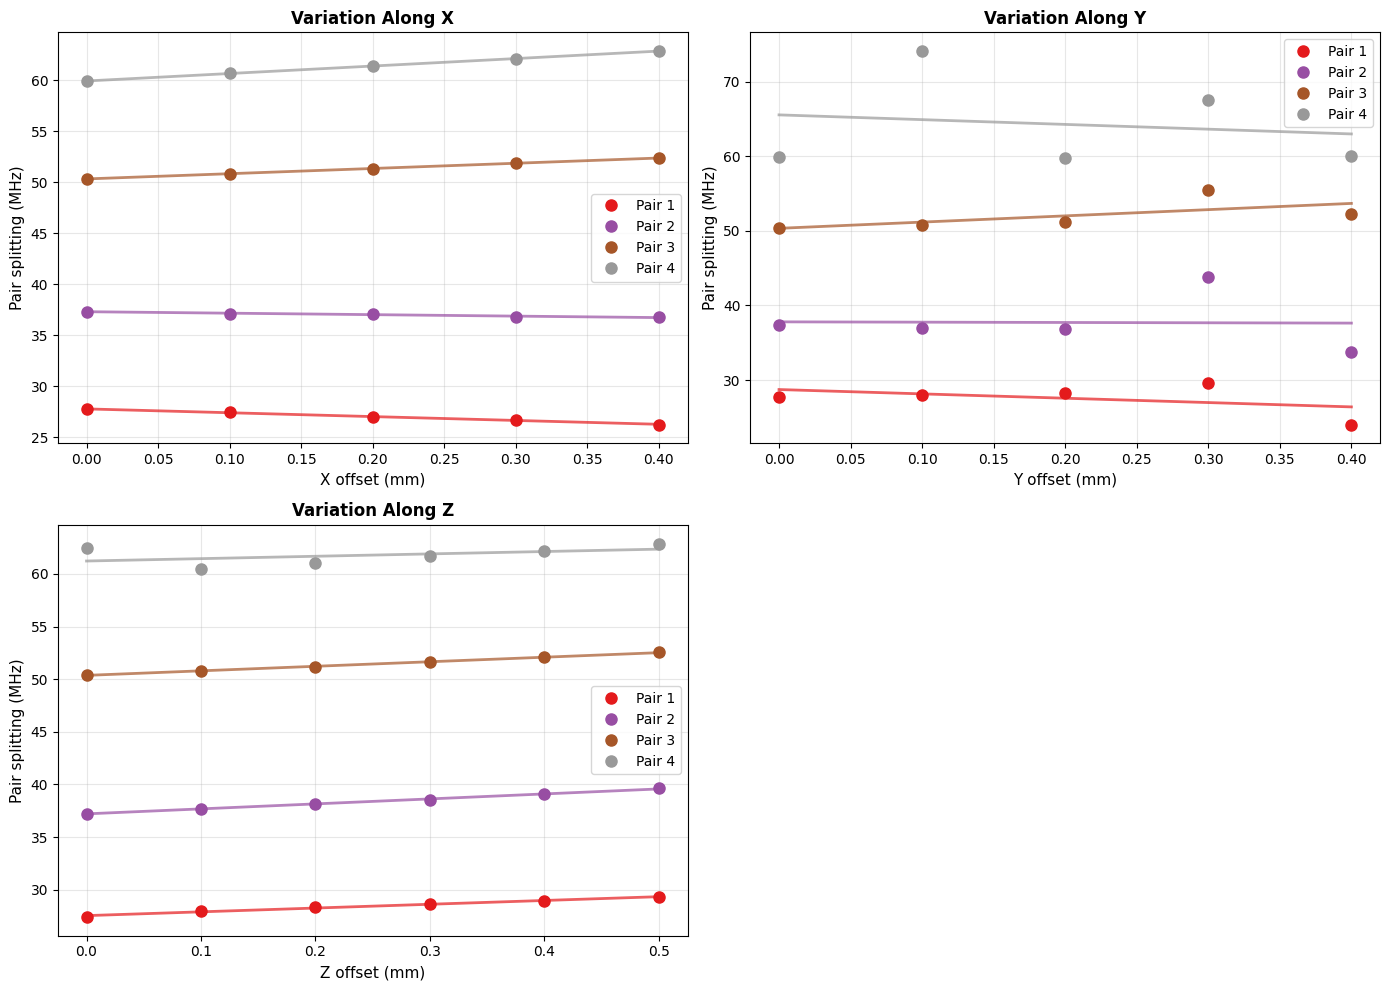

In [22]:
# Plot measured pair splittings and linear fits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

variations = ['Variation Along X', 'Variation Along Y', 'Variation Along Z']
directions = ['X', 'Y', 'Z']
colors = plt.cm.Set1(np.linspace(0, 1, 4))

for ax_idx, (direction, variation) in enumerate(zip(directions, variations)):
    ax = axes[ax_idx]
    
    for pair_k in range(1, len(candidate_pairs) + 1):
        if pair_k in pair_data[variation]:
            u_vals = pair_data[variation][pair_k]['u']
            s_vals = pair_data[variation][pair_k]['s'] * 1000  # Convert to MHz
            
            # Linear fit
            m = pair_slopes[direction][pair_k]['m']
            b = pair_slopes[direction][pair_k]['b']
            s_fit = m * u_vals + b
            s_fit *= 1000  # Convert to MHz
            
            ax.plot(u_vals, s_vals, 'o', color=colors[pair_k-1], label=f'Pair {pair_k}', markersize=8)
            ax.plot(u_vals, s_fit, '-', color=colors[pair_k-1], linewidth=2, alpha=0.7)
    
    ax.set_xlabel(f'{direction} offset (mm)', fontsize=11)
    ax.set_ylabel('Pair splitting (MHz)', fontsize=11)
    ax.set_title(f'{variation}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

# Remove the 4th subplot
fig.delaxes(axes[3])

plt.tight_layout()
plt.savefig('pair_splittings_fits.png', dpi=150)
print("\nSaved: pair_splittings_fits.png")
plt.close

In [23]:
# Save detailed results
results_summary = {
    'magnitude': np.linalg.norm(best_b0),
    'b0_x': best_b0[0],
    'b0_y': best_b0[1],
    'b0_z': best_b0[2],
    'best_permutation': best_perm_idx,
    'residual': best_residual
}

results_df = pd.DataFrame([results_summary])
results_df.to_csv('field_reconstruction_results.csv', index=False)
print("Saved: field_reconstruction_results.csv")

# Save H matrix
np.savetxt('response_matrix_H.txt', H, fmt='%.8f', 
           header='Apparatus response matrix H (mT/mm)\nRows: Bx, By, Bz\nColumns: X, Y, Z')
print("Saved: response_matrix_H.txt")

# Save axis assignment
assignment_df = pd.DataFrame([
    {
        'pair_k': pair_k,
        'left_dip': candidate_pairs[pair_k-1][0],
        'right_dip': candidate_pairs[pair_k-1][1],
        'assigned_nv_axis': assignment[pair_k],
        'nv_x': NV_AXES[assignment[pair_k]-1, 0],
        'nv_y': NV_AXES[assignment[pair_k]-1, 1],
        'nv_z': NV_AXES[assignment[pair_k]-1, 2]
    }
    for pair_k in range(1, len(candidate_pairs) + 1)
])
assignment_df.to_csv('dip_pair_assignment.csv', index=False)
print("Saved: dip_pair_assignment.csv")

print("\nAll results saved to CSV files.")

Saved: field_reconstruction_results.csv
Saved: response_matrix_H.txt
Saved: dip_pair_assignment.csv

All results saved to CSV files.
